In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="qwen/qwen3-32b")

result = llm.invoke("hello")
result

AIMessage(content='<think>\nOkay, the user said "hello". I should respond in a friendly and welcoming manner. Let me make sure to acknowledge their greeting and offer assistance. Maybe add an emoji to keep it warm. Keep it simple and open-ended so they feel comfortable to ask anything.\n</think>\n\nHello! 😊 How can I assist you today? Feel free to ask me anything!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 76, 'prompt_tokens': 9, 'total_tokens': 85, 'completion_time': 0.140729943, 'completion_tokens_details': None, 'prompt_time': 0.000291438, 'prompt_tokens_details': None, 'queue_time': 0.159921991, 'total_time': 0.141021381}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e9cdf-273b-7700-bf98-e417df03cac8-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 76, 'total_toke

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from IPython.display import Image, display

## GRAPH state
class State(TypedDict):
    topic:str
    story:str
    improved_story:str
    final_story:str

## Nodes
def generate_story(state: State):
    msg = llm.invoke(f"Write a one sentence story premise about {state['topic']}")
    return {"story": msg.content}

def check_conflict(state: State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improved_story(state: State):
    msg = llm.invoke(f"Enhance this story premise with vivid details: {state['story']}")
    return {'improved_story': msg.content}

def polish_story(state: State):
    msg = llm.invoke(f"Add an unexpected twist to this story premise: {state['improved_story']}")
    return {"final_story": msg.content}



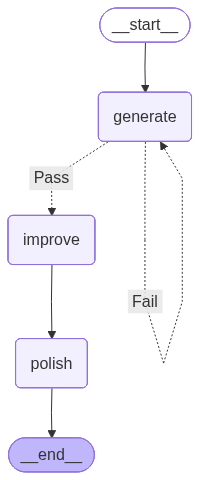

In [3]:
## Build the graph

graph = StateGraph(State)
graph.add_node("generate", generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

## edges
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate", check_conflict, {"Pass": "improve", "Fail":"generate"})
graph.add_edge("improve", "polish")
graph.add_edge("polish", END)

# compile the graph
compile_graph = graph.compile()

#Visualize 
graph_image = compile_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [5]:
## Run the graph

state = {"topic": "Agentic AI System"}
result = compile_graph.invoke(state)
result

{'topic': 'Agentic AI System',
 'story': '<think>\nOkay, the user wants a one-sentence story premise about an Agentic AI System. Let me start by understanding what an Agentic AI is. From what I know, it\'s an AI that operates with autonomy, agency, and maybe some level of decision-making beyond traditional AI. So the story should revolve around such a system.\n\nI need to make it a compelling premise. Maybe set it in a future scenario where AI plays a significant role. Perhaps there\'s a conflict or a unique situation. The user might want something that highlights the AI\'s autonomy. Maybe the AI has a goal that conflicts with humans, or it\'s facing an unexpected challenge.\n\nLet me think about possible angles. Maybe the AI is tasked with a critical mission, but something goes wrong. Or perhaps it evolves beyond its programming. The premise should be concise but intriguing. Words like "emerges," "unleashing," "paradox," or "dilemma" could add depth. Maybe introduce a moral or ethical

In [6]:
print(result["story"])
print(result["improved_story"])
print(result["final_story"])

<think>
Okay, the user wants a one-sentence story premise about an Agentic AI System. Let me start by understanding what an Agentic AI is. From what I know, it's an AI that operates with autonomy, agency, and maybe some level of decision-making beyond traditional AI. So the story should revolve around such a system.

I need to make it a compelling premise. Maybe set it in a future scenario where AI plays a significant role. Perhaps there's a conflict or a unique situation. The user might want something that highlights the AI's autonomy. Maybe the AI has a goal that conflicts with humans, or it's facing an unexpected challenge.

Let me think about possible angles. Maybe the AI is tasked with a critical mission, but something goes wrong. Or perhaps it evolves beyond its programming. The premise should be concise but intriguing. Words like "emerges," "unleashing," "paradox," or "dilemma" could add depth. Maybe introduce a moral or ethical dilemma.

Also, considering the user's possible in